In [1]:
from matplotlib.pyplot import xlabel
import matplotlib.pyplot as plt
import numpy as np
#import matplotlib.ticker as ticker
import statistics
import math
#from numpy.lib.function_base import append

import astropy.units as u
from specutils import Spectrum1D
from specutils.manipulation import FluxConservingResampler
from astropy.nddata import StdDevUncertainty








In [2]:
###  older versions

file1='SN2022hrs_G230L_20220422.33.dat'
file2='SN2022hrs_G230L_20220422.39.dat'
file3='SN2022hrs_G230L_20220422.46.dat'
file4='SN2022hrs_G230L_20220422.52.dat'
file5='SN2022hrs_G430L_20220422.32.dat'
files=['SN2022hrs_G230L_20220422.33.dat','SN2022hrs_G230L_20220422.39.dat','SN2022hrs_G230L_20220422.46.dat','SN2022hrs_G230L_20220422.52.dat','SN2022hrs_G430L_20220422.32.dat']


outputfilename = "SN20222hrs_muv_20220422.4_50"
filename = "SN2022hrs_muv_20220422.4_50"
binsize = 50


files=['SN2022hrs_G430L_20220426_1.dat','SN2022hrs_G230L_20220426_1.dat', 'SN2022hrs_G230L_20220426_2.dat', 'SN2022hrs_G230L_20220426_3.dat','SN2022hrs_G430L_20220427_1.dat','SN2022hrs_G230L_20220427_1.dat','SN2022hrs_G230L_20220427_2.dat','SN2022hrs_G230L_20220427_3.dat']


opticalfile='SN2022hrs_20220425_redblu_100756.570.ascii'

outputfilename = "SN20222hrs_muv_20220426.3_20"
filename = "SN2022hrs_muv_20220426.3_20"
binsize = 20



files=['SN2022hrs_G430L_20220507_1.dat','SN2022hrs_G230L_20220507_1.dat', 'SN2022hrs_G230L_20220507_2.dat', 'SN2022hrs_G230L_20220507_3.dat']


opticalfile='SN2022hrs_20220509_redblu_091438.492.ascii'

outputfilename = "SN20222hrs_muv_20220506.9_20"
filename = "SN2022hrs_muv_20220506.9_20"
binsize = 20



files=['SN2022hrs_G430L_20220515_1.dat','SN2022hrs_G230L_20220515_1.dat', 'SN2022hrs_G230L_20220515_2.dat', 'SN2022hrs_G230L_20220515_3.dat']


opticalfile='SN2022hrs_20220517_redblu_132705.365.ascii'

outputfilename = "SN20222hrs_muv_20220514.9_20"
filename = "SN2022hrs_muv_20220514.9_20"
binsize = 20



files=['SN2022hrs_G430L_20220427_1.dat','SN2022hrs_G230L_20220427_1.dat', 'SN2022hrs_G230L_20220427_2.dat', 'SN2022hrs_G230L_20220427_3.dat']


opticalfile='SN2022hrs_20220425_redblu_100756.570.ascii'

outputfilename = "SN20222hrs_muv_20220427.3_40"
filename = "SN2022hrs_muv_20220427.3_40"
binsize = 40



In [3]:


files=['SN2022hrs_G430L_20220523_1.dat','SN2022hrs_G230L_20220523_1.dat', 'SN2022hrs_G230L_20220523_2.dat', 'SN2022hrs_G230L_20220523_3.dat']


opticalfile='SN2022hrs_220523.tsv'

outputfilename = "SN20222hrs_muv_20220523_40"
filename = "SN2022hrs_muv_20220523_40"
binsize = 40


files=['SN2022hrs_G430L_20220523_1.dat','SN2022hrs_G230L_20220523_1.dat', 'SN2022hrs_G230L_20220523_2.dat', 'SN2022hrs_G230L_20220523_3.dat']


opticalfile='SN2022hrs_220523.csv'

outputfilename = "SN20222hrs_muv_20220523_20"
filename = "SN2022hrs_muv_20220523_20"
binsize = 20

outputfilename = "SN20222hrs_muv_20220523_10"
filename = "SN2022hrs_muv_20220523_10"
binsize = 10



In [4]:



optwave = []
optflux = []
wavelength1 = []
flux1 = []
fluxmean = []
wavelengthcompile = []
fluxcompile = []
uncertaintycompile = []
dataqualitycompile = []
dataquality1 = []
#for weighted mean
fluxmeangroup = []
weightsgroup = []
wavelength = []
wavelengthb = []
flux = []
fluxb = []
fluxc = []
dataquality = []
dataqualityb = []
#uncertainties for weights
uncertainty1 = []
uncertainty = []
uncertaintyb = []
count = 0
certainty = 0
#can have a string of spectra so once complete, it can run through it with all the files

with open(opticalfile,'r') as f:
    for line in f:
        #print(line)
        content = line.split()
        optwave.append(float(content[0]))
        optflux.append(float(content[1]))




for file in files:
    with open(file,'r') as f:
        for line in f:
            content = line.split()
            for num in range(0, (len(content)-3)):
                wavelength1.append(content[0])
                flux1.append(content[1])
                uncertainty1.append(content[2])
                dataquality1.append(content[3])
       


#making all data into floats
wavelength1 = [float(x) for x in wavelength1]
for x in wavelength1:
    wavelengthcompile.append(x)


flux1 = [float(x) for x in flux1]
for x in flux1:
    fluxcompile.append(x)

uncertainty1 = [float(x) for x in uncertainty1]
for x in uncertainty1:
    uncertaintycompile.append(x)

dataquality1 = [float(x) for x in dataquality1]
for x in dataquality1:
    dataqualitycompile.append(x)

#taking only data within 1600-5650 wv
length = wavelengthcompile


for x in range(0,len(length)):
    #print(x)
    if((wavelengthcompile[x] > 1600) and (wavelengthcompile[x] < 5650) and (dataqualitycompile[x] != 16912)):
        #print(x)
        wavelength.append(wavelengthcompile[x])
        flux.append(fluxcompile[x])
        uncertainty.append(uncertaintycompile[x])
        dataquality.append(dataqualitycompile[x])



#sorting them by wavelength
wavelength = np.array(wavelength)
flux = np.array(flux)
uncertainty = np.array(uncertainty)
dataquality = np.array(dataquality)

inds = wavelength.argsort()
flux = flux[inds]
wavelength = wavelength[inds]
uncertainty = uncertainty[inds]
dataquality = dataquality[inds]


#plt.plot(wavelength, flux, 'b-', label = "combined", alpha = 1, linewidth = .9)
#plt.yscale('log')
#plt.legend()
#plt.show()


min=math.ceil(min(wavelength)/binsize)*binsize
max=math.floor(max(wavelength/binsize))*binsize
#print(min, max)

newwave=[]
for w in range(min, max, binsize):
    newwave.append(w)


input_spectra = Spectrum1D( flux=flux*u.erg/u.s/u.cm/u.cm/u.angstrom, spectral_axis=np.array(wavelength)*u.angstrom, uncertainty=StdDevUncertainty(uncertainty) )

    

# , uncertainty=uncertainty 

flux_rebinned = FluxConservingResampler()
newflux = flux_rebinned(input_spectra, newwave*u.angstrom) 





        Use Spectrum instead. [warnings]


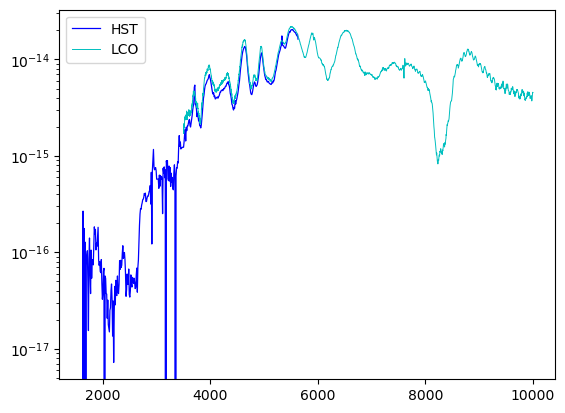

In [5]:

plt.plot(newwave, newflux.flux, 'b-', label = "HST", alpha = 1, linewidth = .9)



plt.plot(optwave, optflux, 'c-', label = "LCO", alpha = 1, linewidth = .7)
plt.yscale('log')
plt.legend()

#axes = plt.axes()
#axes.set_xlim([1600,9000])
#axes.set_ylim([10**(-20),10**(-16)])
plt.savefig((str(filename) + ".png"))


plt.show()





In [6]:
f = open(filename + ".dat", "x")
for x in range(0, len(newwave)):
    f.write(str(newwave[x]) + " " + str(newflux[x].flux.value))
    f.write("\n")  
f.close()

